In [1]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
from scipy.optimize import curve_fit
import json


In [2]:
# import sys
# sys.path.append('/home/pkruyt/cernbox/CERN-coolers/LEIR/ions')

# from ion_properties import ions, IonProperties

In [3]:
# context = xo.ContextCpu(omp_num_threads=4)
context = xo.ContextCpu()

with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
particle_ref0=line.particle_ref
line.build_tracker()

clight=constants.speed_of_light
circumference = line.get_length()
twiss=line.twiss()
#%%
###################
# Linear Transfer #
###################

qx=twiss['qx']
qy=twiss['qy']
dqx=twiss['dqx']
dqy=twiss['dqy']
circumference=twiss['s'][-1]
# beta_x=twiss['betx'][-1]
# beta_y=twiss['bety'][-1]

qs=twiss['qs']
bets=twiss['bets0']
voltage_rf=7*1e6
frequency=201.8251348335775*1e6
lag_rf=180
momentum_compaction_factor=twiss['momentum_compaction_factor']
slip_factor=['slip_factor']

# qs=0.0131
# bets=0.063/2e-4

#at interaction points: #from https://anaconda.org/petrenko/li_like_ca_in_sps/notebook
beta_x  =  54.614389 # m
beta_y  =  44.332517 # m
alpha_x = -1.535235
alpha_y =  1.314101

Dx  =  2.444732 # m
Dpx =  0.097522


Dy  =  0.0 # m
Dpy =  0.0

#index of gamma factory along SPS line: 16675

arc = xt.LineSegmentMap(
        qx=qx, qy=qy,
        dqx=0, dqy=0,
        length=circumference,
        alfx=alpha_x,
        alfy=alpha_y,
        betx=beta_x,
        bety=beta_y,
        
        dx=Dx,
        dpx=Dpx,
        dy=Dy,
        dpy=Dpy,
        # qs=qs,
        # bets=bets,
        voltage_rf=voltage_rf,
        lag_rf=lag_rf,
        frequency_rf=frequency,
        momentum_compaction_factor=momentum_compaction_factor,
        longitudinal_mode = 'nonlinear',

        )

Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [4]:
from ion_properties import lead,calcium,xenon,xenon2nd


In [5]:
# injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
# injection_dp_p = 2e-4
# sigma_z = 0.063 #https://cds.cern.ch/record/2690736/files/SPSC-I-253.pdf


Loop over both sig_delta and emittance

In [6]:
sig_delta_list = np.linspace(2e-5, 2.2e-4, 2)
sig_delta_list = np.linspace(2e-5, 2.2e-4, 50)
n_emitt_list=np.linspace(1e-7,1.7e-6,1)
dp_p_list=[]
# sig_delta_list = np.linspace(0.4e-4, 1e-4, 10)
# n_emitt_list=np.linspace(0.5e-6,1.5e-6,10)


transverse_cooling_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))
longitudinal_growth_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))

for ion_loop in [lead]:
        # Ion properties:
        q0 = ion_loop.q0
        mass0 = ion_loop.mass0

        gamma = ion_loop.gamma_cooling
        beta=  np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion_loop.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref


        #nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z = ion_loop.bunch_length #m



        num_particles=int(5e3)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()


        for j, n_emitt_loop in (enumerate(n_emitt_list)):
            print(f'{j+1}/{len(n_emitt_list)}')    
            for k, sig_delta_loop in tqdm(enumerate(sig_delta_list)):
                sigma_dp = sigma_z / np.abs(twiss['bets0'])
                sigma_z=sig_delta_loop*np.abs(twiss['bets0'])
                particles = xp.generate_matched_gaussian_bunch(
                        num_particles=num_particles,
                        total_intensity_particles=bunch_intensity,
                        nemitt_x=n_emitt_loop, nemitt_y=n_emitt_loop, sigma_z=sigma_z,
                        particle_ref=particle_ref,
                        line=line_arc,        
                        )
                particles._init_random_number_generator()
                dp_p=np.std(particles.delta)
                dp_p_list.append(dp_p)


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1/1


0it [00:00, ?it/s]

Compiling ContextCpu kernels...


1it [00:02,  2.19s/it]

Done compiling ContextCpu kernels.


...

--> Emittance: 0.13610261152027747
*** Maximum RMS bunch length 0.23410655945136172m.
... distance to target bunch length: -6.6103e-02
... distance to target bunch length: 1.5990e-01
... distance to target bunch length: 8.1593e-02
... distance to target bunch length: -4.7219e-03
... distance to target bunch length: 9.2681e-06
... distance to target bunch length: -4.4657e-08
... distance to target bunch length: 3.0955e-07
--> Bunch length: 0.06774192651355014


49it [01:10,  2.83s/it]

--> Emittance: 0.1412821061685166
*** Maximum RMS bunch length 0.23410655945136172m.
... distance to target bunch length: -6.7364e-02
... distance to target bunch length: 1.5862e-01
... distance to target bunch length: 8.3059e-02
... distance to target bunch length: -4.7077e-03
... distance to target bunch length: 2.2247e-05
... distance to target bunch length: -1.0968e-07
... distance to target bunch length: 2.5190e-07
--> Bunch length: 0.06902242804839578


50it [01:13,  1.47s/it]

--> Emittance: 0.1465512011212386


In [7]:
len(dp_p_list)

50

In [8]:
len(sig_delta_list)

50

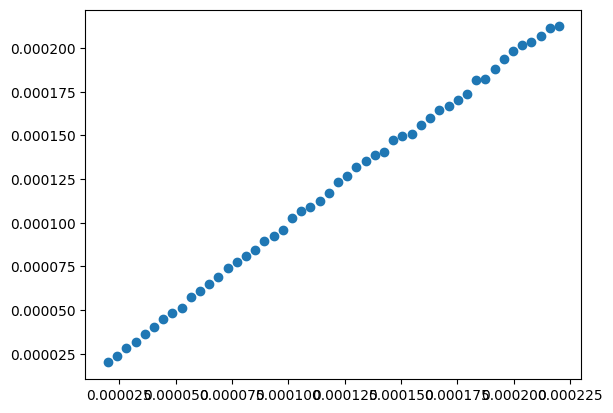

In [9]:
plt.figure()
plt.scatter(sig_delta_list,dp_p_list)
plt.show()

In [10]:
# sig_delta_list = np.linspace(2e-5, 2.2e-4, 2)
# sig_delta_list = np.linspace(2e-5, 2.2e-4, 50)
# n_emitt_list=np.linspace(1e-7,1.7e-6,50)

# # sig_delta_list = np.linspace(0.4e-4, 1e-4, 10)
# # n_emitt_list=np.linspace(0.5e-6,1.5e-6,10)

# sig_delta_list = np.linspace(1e-10, 2.2e-4, 25)
# n_emitt_list=np.linspace(1e-10,1.7e-6,25)

# # sig_delta_list = np.linspace(1e-10, 2.2e-4, 7)
# # n_emitt_list=np.linspace(1e-10,1.7e-6,7)


# transverse_cooling_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))
# longitudinal_growth_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))

# for ion_loop in [lead,xenon]:
#         # Ion properties:
#         q0 = ion_loop.q0
#         mass0 = ion_loop.mass0

#         gamma = ion_loop.gamma_cooling
#         beta=  np.sqrt(1-1/(gamma*gamma))
#         p0c = mass0*gamma*beta #eV/c

#         bunch_intensity = ion_loop.bunch_intensity

#         particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

#         line.particle_ref=particle_ref


#         #nemitt = 1.5e-6 # m*rad (normalized emittance)
#         sigma_z = ion_loop.bunch_length #m



#         num_particles=int(5e3)

#         line_arc=xt.Line(
#                 elements=[arc])
#         line_arc.build_tracker()


#         for j, n_emitt_loop in tqdm(enumerate(n_emitt_list)):
#             print(f'{j+1}/{len(n_emitt_list)}')    
#             for k, sig_delta_loop in enumerate(sig_delta_list):
            
#                 particles = xp.generate_matched_gaussian_bunch(
#                         num_particles=num_particles,
#                         total_intensity_particles=bunch_intensity,
#                         nemitt_x=n_emitt_loop, nemitt_y=n_emitt_loop, sigma_z=sigma_z,
#                         particle_ref=particle_ref,
#                         line=line_arc,        
#                         )
#                 particles._init_random_number_generator()

#                 particles0=particles.copy()
#                 # sigma_dp=2e-4  
#                 sigma_dp=np.std(particles.delta)
#                 print(sigma_dp)
#                 sigma_dp=2e-4  
                
#                 ##################
#                 # Laser Cooler #
#                 ##################

#                 #laser-ion beam collision angle
#                 theta_l = 2.6*np.pi/180 # rad
#                 nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

#                 # Ion excitation energy:
#                 ion_excited_lifetime=ion_loop.excited_lifetime
#                 hw0 = ion_loop.hw0 # eV
#                 hc=constants.hbar*clight/constants.e # eV*m (ħc)
#                 lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

#                 lambda_l = ion_loop.lambda_l

#                 # # Shift laser wavelength for fast longitudinal cooling:5
#                 # lambda_l = lambda_l*(1+1*sigma_dp) # m

#                 laser_frequency = clight/lambda_l # Hz
#                 sigma_w = 2*np.pi*laser_frequency*sigma_dp
#                 #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

#                 sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
#                 print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
#                 print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

#                 laser_waist_radius = 1.3e-3 #m
#                 laser_energy = 5e-3
#                 laser_x = ion_loop.laser_x
               
#                 GF_IP = xt.PulsedLaser(
#                                 laser_x=laser_x,
#                                 laser_y=0,
#                                 laser_z=0,
                                
#                                 laser_direction_nx = 0,
#                                 laser_direction_ny = ny,
#                                 laser_direction_nz = nz,
#                                 laser_energy         = laser_energy, # J
#                                 laser_duration_sigma = sigma_t, # sec
#                                 laser_wavelength = lambda_l, # m
#                                 laser_waist_radius = laser_waist_radius, # m
#                                 laser_waist_shift = 0, # m
#                                 ion_excitation_energy = hw0, # eV
#                                 ion_excited_lifetime  = ion_excited_lifetime, # sec                   
#                                 )

#                 # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
#                 max_time_s = 1
#                 int_time_s = 0.01
#                 T_per_turn = circumference/(clight*beta)
#                 num_turns = int(max_time_s/T_per_turn)
#                 save_interval = int(int_time_s/T_per_turn)

#                 # num_turns = int(1e3)
#                 # save_interval = num_turns/100
#                 # # save_interval=1

#                 # create a monitor object, to reduce holded data
#                 monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
#                                         n_repetitions=int(num_turns/save_interval),
#                                         repetition_period=save_interval,
#                                         num_particles=num_particles)


#                 # line.discard_tracker()
#                 # IP_index=16675   
#                 # line.insert_element('monitor', element=monitor, index=IP_index)
#                 # line.insert_element('GF_IP', element=GF_IP, index=IP_index) #this way monitor comes after the laser
#                 # SPS_line.append_element(monitor,'monitor')
#                 # SPS_line.append_element(GF_IP,'GF_IP')
                            
#                 particles=particles0.copy()

#                 line = xt.Line(
#                         elements=[monitor,GF_IP,arc])

#                 context = xo.ContextCpu(omp_num_threads=1)
#                 line.build_tracker(_context=context)
#                 # line.optimize_for_tracking()

#                 line.track(particles, num_turns=num_turns,
#                         turn_by_turn_monitor=False,with_progress=False)

#                 # extract relevant values
#                 x = monitor.x[:,:,0]
#                 px = monitor.px[:,:,0]
#                 y = monitor.y[:,:,0]
#                 py = monitor.py[:,:,0]
#                 delta = monitor.delta[:,:,0]
#                 zeta = monitor.zeta[:,:,0]
#                 state = monitor.state[:,:,0]
#                 time = monitor.at_turn[:, 0, 0] * T_per_turn

#                 gamma_x=(1+alpha_x**2)/beta_x
#                 gamma_y=(1+alpha_y**2)/beta_y

#                 action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
#                 action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

#                 emittance_x=np.mean(action_x,axis=1)*gamma/2

#                 # Define the exponential function
#                 def exponential_func(x, a, b):
#                         return a * np.exp(x * b)
                
#                 # Fit the data to the exponential function
#                 params_transverse, covariance = curve_fit(exponential_func, time, emittance_x)

#                 # Extract the parameters
#                 a, b = params_transverse

#                 transverse_cooling_rate=b

                

#                 # plt.plot(time,emittance_x*1e6, linewidth=5.0)
#                 # plt.plot(time, exponential_func(time,
#                 # *params_transverse) * 1e6, linestyle='--')
                
#                 # Fit the data to the exponential function
#                 rms_dp_p = np.std(delta, axis=1)
#                 window_size = 10  # or any other suitable value
#                 rms_dp_p_smoothed = np.convolve(rms_dp_p, np.ones(window_size)/window_size, mode='valid')


#                 params_longitudinal, covariance = curve_fit(exponential_func, time[:len(rms_dp_p_smoothed)], rms_dp_p_smoothed)

#                 # Extract the parameters
#                 a, b = params_longitudinal

#                 longitudinal_growth_rate=b

                
    
    
#                 transverse_cooling_rate_array[k, j] = transverse_cooling_rate
#                 longitudinal_growth_rate_array[k, j] = longitudinal_growth_rate

# np.savez(f'results/cooling_rate_scan/{ion_loop.name}.npz',
#             transverse_cooling_rate_array=transverse_cooling_rate_array,
#             longitudinal_growth_rate_array=longitudinal_growth_rate_array,
#             sig_delta_list=sig_delta_list,
#             n_emitt_list=n_emitt_list
#             )

In [ ]:
sig_delta_list = np.linspace(2e-5, 2.2e-4, 7)
n_emitt_list=np.linspace(1e-7,1.7e-6,7 )

sig_delta_list = np.linspace(1e-10, 2.2e-4, 40)
n_emitt_list=np.linspace(1e-10,1.7e-6,40)



transverse_cooling_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))
longitudinal_growth_rate_array = np.zeros((len(sig_delta_list), len(n_emitt_list)))

for ion_loop in [calcium]:
        # Ion properties:
        q0 = ion_loop.q0
        mass0 = ion_loop.mass0

        gamma = ion_loop.gamma_cooling
        beta=  np.sqrt(1-1/(gamma*gamma))
        p0c = mass0*gamma*beta #eV/c

        bunch_intensity = ion_loop.bunch_intensity

        particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0,gamma0=gamma)

        line.particle_ref=particle_ref


        #nemitt = 1.5e-6 # m*rad (normalized emittance)
        sigma_z = ion_loop.bunch_length #m



        num_particles=int(5e3)

        line_arc=xt.Line(
                elements=[arc])
        line_arc.build_tracker()


        for j, n_emitt_loop in tqdm(enumerate(n_emitt_list)):
            print(f'{j+1}/{len(n_emitt_list)}')    
            for k, sig_delta_loop in enumerate(sig_delta_list):
                sigma_dp = sigma_z / np.abs(twiss['bets0'])
                sigma_z=sig_delta_loop*np.abs(twiss['bets0'])
            
                particles = xp.generate_matched_gaussian_bunch(
                        num_particles=num_particles,
                        total_intensity_particles=bunch_intensity,
                        nemitt_x=n_emitt_loop, nemitt_y=n_emitt_loop, sigma_z=sigma_z,
                        particle_ref=particle_ref,
                        line=line_arc,        
                        )
                particles._init_random_number_generator()

                particles0=particles.copy()
                # sigma_dp=2e-4  
                sigma_dp=np.std(particles.delta)
                print(sigma_dp)
                sigma_dp=2e-4  
                
                ##################
                # Laser Cooler #
                ##################

                #laser-ion beam collision angle
                theta_l = 2.6*np.pi/180 # rad
                #theta_l=ion_loop.theta_l
                nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

                # Ion excitation energy:
                ion_excited_lifetime=ion_loop.excited_lifetime
                hw0 = ion_loop.hw0 # eV
                hc=constants.hbar*clight/constants.e # eV*m (ħc)
                lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

                lambda_l = ion_loop.lambda_l

                # # Shift laser wavelength for fast longitudinal cooling:5
                # lambda_l = lambda_l*(1+1*sigma_dp) # m

                laser_frequency = clight/lambda_l # Hz
                sigma_w = 2*np.pi*laser_frequency*sigma_dp
                #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

                sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
                print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
                print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

                laser_waist_radius = 1.3e-3 #m
                laser_energy = 5e-3
                #laser_energy = ion.pulse_energy
                laser_x = ion_loop.laser_x
               
                GF_IP = xt.PulsedLaser(
                                laser_x=laser_x,
                                laser_y=0,
                                laser_z=0,
                                
                                laser_direction_nx = 0,
                                laser_direction_ny = ny,
                                laser_direction_nz = nz,
                                laser_energy         = laser_energy, # J
                                laser_duration_sigma = sigma_t, # sec
                                laser_wavelength = lambda_l, # m
                                laser_waist_radius = laser_waist_radius, # m
                                laser_waist_shift = 0, # m
                                ion_excitation_energy = hw0, # eV
                                ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                                )

                # simulation parameters: simulate 10 s of cooling, and take data once every 100 ms
                max_time_s = 1
                int_time_s = 0.01
                T_per_turn = circumference/(clight*beta)
                num_turns = int(max_time_s/T_per_turn)
                save_interval = int(int_time_s/T_per_turn)

                # num_turns = int(1e3)
                # save_interval = num_turns/100
                # # save_interval=1

                # create a monitor object, to reduce holded data
                monitor = xt.ParticlesMonitor(start_at_turn=0, stop_at_turn=1,
                                        n_repetitions=int(num_turns/save_interval),
                                        repetition_period=save_interval,
                                        num_particles=num_particles)


                # line.discard_tracker()
                # IP_index=16675   
                # line.insert_element('monitor', element=monitor, index=IP_index)
                # line.insert_element('GF_IP', element=GF_IP, index=IP_index) #this way monitor comes after the laser
                # SPS_line.append_element(monitor,'monitor')
                # SPS_line.append_element(GF_IP,'GF_IP')
                            
                particles=particles0.copy()

                line = xt.Line(
                        elements=[monitor,GF_IP,arc])

                context = xo.ContextCpu(omp_num_threads=1)
                line.build_tracker(_context=context)
                # line.optimize_for_tracking()

                line.track(particles, num_turns=num_turns,
                        turn_by_turn_monitor=False,with_progress=False)

                # extract relevant values
                x = monitor.x[:,:,0]
                px = monitor.px[:,:,0]
                y = monitor.y[:,:,0]
                py = monitor.py[:,:,0]
                delta = monitor.delta[:,:,0]
                zeta = monitor.zeta[:,:,0]
                state = monitor.state[:,:,0]
                time = monitor.at_turn[:, 0, 0] * T_per_turn

                gamma_x=(1+alpha_x**2)/beta_x
                gamma_y=(1+alpha_y**2)/beta_y

                action_x = (gamma_x*(x-Dx*delta)**2 + 2*alpha_x*(x-Dx*delta)*(px-Dpx*delta)+ beta_x*(px-Dpx*delta)**2)
                action_y = (gamma_y*(y-Dy*delta)**2 + 2*alpha_y*(y-Dy*delta)*(py-Dpy*delta)+ beta_y*(py-Dpy*delta)**2)

                emittance_x=np.mean(action_x,axis=1)*gamma/2

                # Calculate mean and standard deviation along the particle axis (axis=1)
                mean_z = np.mean(zeta, axis=1)
                mean_delta = np.mean(delta, axis=1)
                sigma_z = np.std(zeta, axis=1)
                sigma_delta = np.std(delta, axis=1)

                # Calculate the covariance between zeta and delta for each turn
                cov_z_delta = np.mean(zeta * delta, axis=1) - mean_z * mean_delta

                # Calculate longitudinal emittance for each turn
                longitudinal_emittance = np.sqrt(sigma_z**2 * sigma_delta**2 - cov_z_delta**2)

                # Define the exponential function
                def exponential_func(x, a, b):
                        return a * np.exp(x * b)
                
                # Fit the data to the exponential function
                params_transverse, covariance = curve_fit(exponential_func, time, emittance_x)

                # Extract the parameters
                a, b = params_transverse

                transverse_cooling_rate=b

                
                params_longitudinal, covariance = curve_fit(exponential_func, time, longitudinal_emittance)

                # Extract the parameters
                a, b = params_longitudinal

                longitudinal_growth_rate=b

    
                transverse_cooling_rate_array[k, j] = transverse_cooling_rate
                longitudinal_growth_rate_array[k, j] = longitudinal_growth_rate

        np.savez(f'results/cooling_rate_scan/{ion_loop.name}.npz',
                transverse_cooling_rate_array=transverse_cooling_rate_array,
                longitudinal_growth_rate_array=longitudinal_growth_rate_array,
                sig_delta_list=sig_delta_list,
                n_emitt_list=n_emitt_list
                )


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


0it [00:00, ?it/s]

1/40
7.109669064632014e-11
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
3.976360619357712e-06
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
8.024898467285366e-06
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.2232396862266109e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.576087211633782e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.99604957567874e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
2.3969406712929594e-05
Laser pulse duration sigma_t =

1it [30:53, 1853.26s/it]

2/40
7.108742249546943e-11
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
4.004319247158812e-06
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
7.964387732350518e-06
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.2088104169347586e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.5858339899198132e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
1.9727333470873527e-05
Laser pulse duration sigma_t = 2.04 ps
Laser wavelength = 768.00 nm
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
2.4040024908918407e-05
Laser pulse duration sigma_

1it [49:08, 2948.38s/it]


KeyboardInterrupt: 